In [19]:
import os
import glob

from enum import Enum, auto

import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [16]:
def run_length_encoding(arr):
    """Run-length encoding for a 1D numpy array."""
    """ return [(val, count), ...] """
    if arr.size == 0:
        return np.array([], dtype=int)
    
    n = arr.size
    rle = []
    count = 1
    for i in range(1, n):
        if arr[i] == arr[i - 1]:
            count += 1
        else:
            rle.append((arr[i - 1], count))
            count = 1
    rle.append((arr[-1], count))  # 마지막 값 추가
    return np.array(rle, dtype=int)


def custom_run_length_encoding(arr):
    """Custom run-length encoding for a 1D numpy array."""
    """ return first value, [count, ...] """
    if arr.size == 0:
        return np.array([], dtype=int)
    
    n = arr.size
    rle = []
    count = 1
    
    first_value = arr[0]
    for i in range(1, n):
        if arr[i] == arr[i - 1]:
            count += 1
        else:
            rle.append(count)
            count = 1
    rle.append(count)  # 마지막 값 추가

    return first_value.item(), np.array(rle, dtype=int)


# rle_vision = run_length_encoding(vision_raw.flatten())
# custom_rle_vision = custom_run_length_encoding(vision_raw.flatten())

In [17]:
def storage_size_comparison_single(rep, idx, vision_raw):
    """
    단일 프레임의 저장 크기를 계산.
    rep, idx 메타데이터와 함께 반환.
    """
    raw_int32 = vision_raw.astype(np.int32)
    raw_uint8 = vision_raw.astype(np.uint8)
    raw_bool = vision_raw.astype(bool)

    sizes = {
        "int32": raw_int32.nbytes,
        "uint8": raw_uint8.nbytes,
        "bool": raw_bool.nbytes,
    }

    flat_bool = raw_bool.flatten().astype(np.uint8)
    rle_vision = run_length_encoding(flat_bool)
    first_val, custom_rle = custom_run_length_encoding(flat_bool)

    rle_size = rle_vision.nbytes
    custom_rle_size = custom_rle.nbytes + np.array([first_val], dtype=custom_rle.dtype).nbytes

    return [rep, idx, sizes["int32"], sizes["uint8"], sizes["bool"], rle_size, custom_rle_size]

In [18]:
def storage_size_statistics(vision_frames):
    """
    모든 프레임에 대해 storage_size_comparison_single을 호출하고
    (rep, idx) 정보와 함께 DataFrame 반환 및 통계 계산.
    """
    results = []
    for rep, idx, vision_frame in vision_frames:
        results.append(storage_size_comparison_single(rep, idx, vision_frame))

    df = pd.DataFrame(results, columns=["rep", "idx", "int32", "uint8", "bool", "RLE", "Custom_RLE"])
    stats = df.describe(numeric_only=True)  # 통계: 숫자 컬럼만
    return df, stats

In [3]:
ex_visions = glob.glob("data/input/src/*/vision")

indexes = {}
for ex_vision in ex_visions:
    df = pd.read_csv(ex_vision, header=None, index_col=0)
    indexes.update({ex_vision.split(os.path.sep)[-2]: df.index.tolist()})

In [21]:
dst_dir = "data/input/dst/"
# npys = glob.glob(os.path.join(dst_dir, "*.npy"))

In [91]:
stats = []
for rep, frames in indexes.items():
    print(f"Processing {rep} with {len(frames)} frames...")
    for frame in tqdm.tqdm(frames):
        if not os.path.exists(os.path.join(dst_dir, rep, f"{frame}.npy")):
            print(f"File {os.path.join(dst_dir, rep, f'{frame}.npy')} does not exist. Skipping.")
            continue
        vision_raw = np.load(os.path.join(dst_dir, rep, f"{frame}.npy"))[Channel.Vision.value]
        stats.append(storage_size_comparison_single(rep, frame, vision_raw))  
    

Processing 438.rep with 11217 frames...


100%|██████████| 11217/11217 [02:19<00:00, 80.59it/s]


File data/input/dst/438.rep/29992.npy does not exist. Skipping.
File data/input/dst/438.rep/29996.npy does not exist. Skipping.
File data/input/dst/438.rep/29999.npy does not exist. Skipping.
File data/input/dst/438.rep/30000.npy does not exist. Skipping.
File data/input/dst/438.rep/30001.npy does not exist. Skipping.
File data/input/dst/438.rep/30002.npy does not exist. Skipping.
File data/input/dst/438.rep/30003.npy does not exist. Skipping.
File data/input/dst/438.rep/30004.npy does not exist. Skipping.
File data/input/dst/438.rep/30005.npy does not exist. Skipping.
File data/input/dst/438.rep/30007.npy does not exist. Skipping.
File data/input/dst/438.rep/30008.npy does not exist. Skipping.
File data/input/dst/438.rep/30009.npy does not exist. Skipping.
File data/input/dst/438.rep/30013.npy does not exist. Skipping.
File data/input/dst/438.rep/30016.npy does not exist. Skipping.
File data/input/dst/438.rep/30017.npy does not exist. Skipping.
File data/input/dst/438.rep/30019.npy do

100%|██████████| 14239/14239 [02:54<00:00, 81.49it/s]


File data/input/dst/36.rep/28330.npy does not exist. Skipping.
Processing 212.rep with 14074 frames...


...

File data/input/dst/212.rep/28252.npy does not exist. Skipping.
Processing 1660.rep with 15768 frames...


100%|██████████| 15768/15768 [02:48<00:00, 93.77it/s]


File data/input/dst/1660.rep/26122.npy does not exist. Skipping.
File data/input/dst/1660.rep/26124.npy does not exist. Skipping.
File data/input/dst/1660.rep/26126.npy does not exist. Skipping.
File data/input/dst/1660.rep/26128.npy does not exist. Skipping.
File data/input/dst/1660.rep/26129.npy does not exist. Skipping.
File data/input/dst/1660.rep/26130.npy does not exist. Skipping.
File data/input/dst/1660.rep/26131.npy does not exist. Skipping.
File data/input/dst/1660.rep/26133.npy does not exist. Skipping.
File data/input/dst/1660.rep/26134.npy does not exist. Skipping.
File data/input/dst/1660.rep/26135.npy does not exist. Skipping.
File data/input/dst/1660.rep/26136.npy does not exist. Skipping.
File data/input/dst/1660.rep/26140.npy does not exist. Skipping.
File data/input/dst/1660.rep/26141.npy does not exist. Skipping.
File data/input/dst/1660.rep/26142.npy does not exist. Skipping.
File data/input/dst/1660.rep/26143.npy does not exist. Skipping.
File data/input/dst/1660.

100%|██████████| 13971/13971 [02:46<00:00, 84.14it/s] 

File data/input/dst/522.rep/27884.npy does not exist. Skipping.
File data/input/dst/522.rep/27899.npy does not exist. Skipping.
File data/input/dst/522.rep/27918.npy does not exist. Skipping.
File data/input/dst/522.rep/27931.npy does not exist. Skipping.
File data/input/dst/522.rep/27935.npy does not exist. Skipping.
File data/input/dst/522.rep/27940.npy does not exist. Skipping.


In [93]:
df = pd.DataFrame(stats, columns=["rep", "idx", "int32", "uint8", "bool", "RLE", "Custom_RLE"])
# df.describe()['']  # 통계: 숫자 컬럼만

In [94]:
df['compression-ratio-RLE'] = df['RLE'] / df['bool']
df['compression-ratio-Custom_RLE'] = df['Custom_RLE'] / df['bool']

In [95]:
df

,rep,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
0,438.rep,34,65536,16384,16384,1344,680,0.082031,0.041504
1,438.rep,46,65536,16384,16384,1344,680,0.082031,0.041504
2,438.rep,54,65536,16384,16384,1328,672,0.081055,0.041016
3,438.rep,58,65536,16384,16384,1328,672,0.081055,0.041016
4,438.rep,73,65536,16384,16384,1328,672,0.081055,0.041016
...,...,...,...,...,...,...,...,...,...
67367,522.rep,27872,65536,16384,16384,8848,4432,0.540039,0.270508
67368,522.rep,27875,65536,16384,16384,8880,4448,0.541992,0.271484
67369,522.rep,27876,65536,16384,16384,8880,4448,0.541992,0.271484
67370,522.rep,27879,65536,16384,16384,8880,4448,0.541992,0.271484


In [121]:
newnew = df.describe()

In [123]:
newnew[['idx', 'int32', 'uint8', 'bool', 'RLE', 'Custom_RLE']] = newnew[['idx', 'int32', 'uint8', 'bool', 'RLE', 'Custom_RLE']].astype(int)

In [124]:
newnew

,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372,67372,67372,67372,67372,67372,67372.000000,67372.000000
mean,15706,65536,16384,16384,7263,3639,0.443329,0.222153
std,7463,0,0,0,2109,1054,0.128778,0.064389
min,26,65536,16384,16384,1328,672,0.081055,0.041016
25%,9715,65536,16384,16384,5584,2800,0.340820,0.170898
50%,16049,65536,16384,16384,7248,3632,0.442383,0.221680
75%,21940,65536,16384,16384,8912,4464,0.543945,0.272461
max,29988,65536,16384,16384,13680,6848,0.834961,0.417969


In [97]:
results = statistics[['bool', 'RLE', 'Custom_RLE', 'compression-ratio-RLE', 'compression-ratio-Custom_RLE']]

In [98]:
results

,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372.0,67372.000000,67372.000000,67372.000000,67372.000000
mean,16384.0,7263.507689,3639.753844,0.443329,0.222153
std,0.0,2109.891863,1054.945932,0.128778,0.064389
min,16384.0,1328.000000,672.000000,0.081055,0.041016
25%,16384.0,5584.000000,2800.000000,0.340820,0.170898
50%,16384.0,7248.000000,3632.000000,0.442383,0.221680
75%,16384.0,8912.000000,4464.000000,0.543945,0.272461
max,16384.0,13680.000000,6848.000000,0.834961,0.417969


In [99]:
results.columns = [
    'Raw vision data', 
    'Conventional RLE',
    'Custom RLE',
    'Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE'
    ]

In [100]:
results['Raw vision data'] = results['Raw vision data'].astype(np.int32)
results['Conventional RLE'] = results['Conventional RLE'].astype(np.int32)
results['Custom RLE'] = results['Custom RLE'].astype(np.int32)
results['Compression ratio w/ Conventional RLE'] = results['Compression ratio w/ Conventional RLE'].astype(np.float32)
results['Compression ratio w/ Custom RLE'] = results['Compression ratio w/ Custom RLE'].astype(np.float32)

/tmp/ipykernel_3513/1239349489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Raw vision data'] = results['Raw vision data'].astype(np.int32)
/tmp/ipykernel_3513/1239349489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Conventional RLE'] = results['Conventional RLE'].astype(np.int32)
/tmp/ipykernel_3513/1239349489.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [101]:
results

,Raw vision data,Conventional RLE,Custom RLE,Compression ratio w/ Conventional RLE,Compression ratio w/ Custom RLE
count,67372,67372,67372,67372.000000,67372.000000
mean,16384,7263,3639,0.443329,0.222153
std,0,2109,1054,0.128778,0.064389
min,16384,1328,672,0.081055,0.041016
25%,16384,5584,2800,0.340820,0.170898
50%,16384,7248,3632,0.442383,0.221680
75%,16384,8912,4464,0.543945,0.272461
max,16384,13680,6848,0.834961,0.417969


In [102]:
res = results.transpose()[['mean', 'std']].transpose()
res['Raw vision data'] = res['Raw vision data'].astype(np.int32)
res['Conventional RLE'] = res['Conventional RLE'].astype(np.int32)
res['Custom RLE'] = res['Custom RLE'].astype(np.int32)

In [103]:
res

,Raw vision data,Conventional RLE,Custom RLE,Compression ratio w/ Conventional RLE,Compression ratio w/ Custom RLE
mean,16384,7263,3639,0.443329,0.222153
std,0,2109,1054,0.128778,0.064389


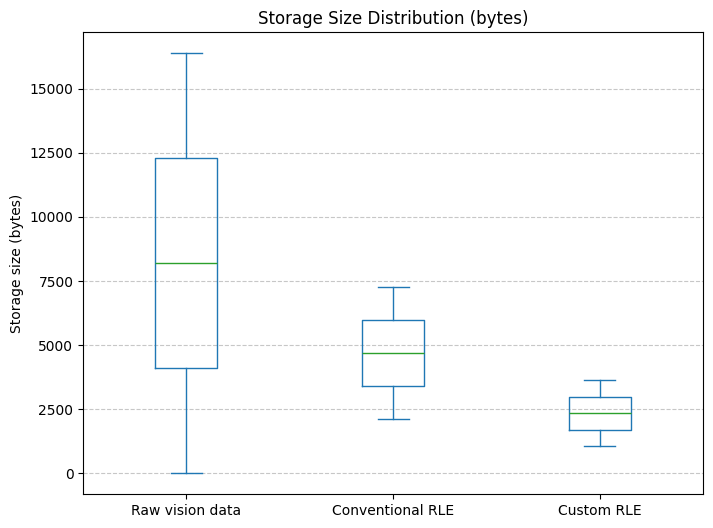

In [104]:
import matplotlib.pyplot as plt

# df가 위의 데이터를 포함하고 있다고 가정
columns = ['Raw vision data', 'Conventional RLE', 'Custom RLE']

# Boxplot 생성
res[columns].plot(kind='box', figsize=(8, 6), title='Storage Size Distribution (bytes)')

plt.ylabel('Storage size (bytes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [110]:
statistics

,idx,int32,uint8,bool,RLE,Custom_RLE,compression-ratio-RLE,compression-ratio-Custom_RLE
count,67372.000000,67372.0,67372.0,67372.0,67372.000000,67372.000000,67372.000000,67372.000000
mean,15706.944294,65536.0,16384.0,16384.0,7263.507689,3639.753844,0.443329,0.222153
std,7463.991484,0.0,0.0,0.0,2109.891863,1054.945932,0.128778,0.064389
min,26.000000,65536.0,16384.0,16384.0,1328.000000,672.000000,0.081055,0.041016
25%,9715.000000,65536.0,16384.0,16384.0,5584.000000,2800.000000,0.340820,0.170898
50%,16049.000000,65536.0,16384.0,16384.0,7248.000000,3632.000000,0.442383,0.221680
75%,21940.000000,65536.0,16384.0,16384.0,8912.000000,4464.000000,0.543945,0.272461
max,29988.000000,65536.0,16384.0,16384.0,13680.000000,6848.000000,0.834961,0.417969


In [111]:
new_df = df[['bool', 'RLE', 'Custom_RLE', 'compression-ratio-RLE', 'compression-ratio-Custom_RLE']]

In [113]:
new_df.columns = [
    'Raw vision data', 
    'Conventional RLE',
    'Custom RLE',
    'Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE'
    ]

<Axes: title={'center': 'Storage Size Distribution (bytes)'}>

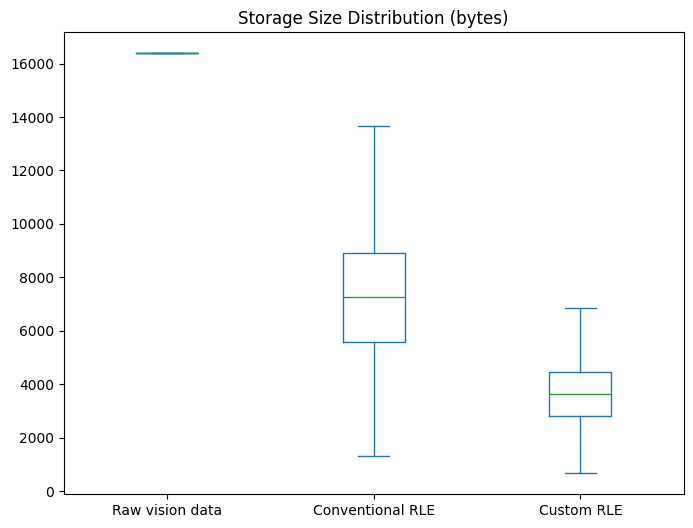

In [115]:
new_df[['Raw vision data', 
    'Conventional RLE',
    'Custom RLE']].plot(kind='box', figsize=(8, 6), title='Storage Size Distribution (bytes)')

<Axes: title={'center': 'Compression Ratio Distribution'}>

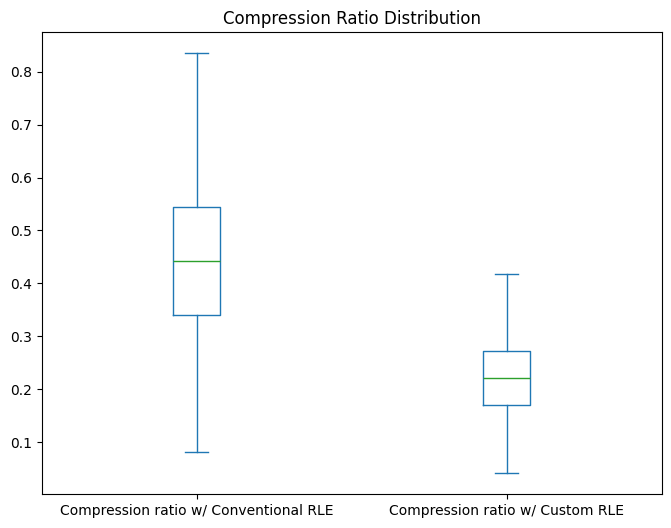

In [117]:
new_df[['Compression ratio w/ Conventional RLE',
    'Compression ratio w/ Custom RLE']].plot(kind='box', figsize=(8, 6), title='Compression Ratio Distribution')